In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm

In [110]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(3,32),
            nn.Tanh(),
            nn.Linear(32,64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,1)
        )
    
    def forward(self,t,y1,y2):
        x=torch.cat([t,y1,y2],dim=1)
        return self.net(x)

In [111]:
def black_scholes(S, K=100, T=1000, r=0.05, sigma=0.1, option_type='call'):
    """
    Calculates the theoretical price of a European option.
    
    Parameters:
    S : float : Current stock price
    K : float : Strike price
    T : float : Time to maturity (in years)
    r : float : Risk-free interest rate (annualized)
    sigma : float : Volatility of the underlying asset (annualized)
    option_type : str : 'call' or 'put'
    """
    # Handle the boundary condition at expiration
    if T <= 0:
        if option_type == 'call':
            return max(0.0, S - K)
        elif option_type == 'put':
            return max(0.0, K - S)
        else:
            raise ValueError("Invalid option_type. Use 'call' or 'put'.")

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate the option price
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option_type. Use 'call' or 'put'.")
        
    return price

In [112]:
model=PINN()
model.load_state_dict(torch.load('model.pth', weights_only=True))

<All keys matched successfully>

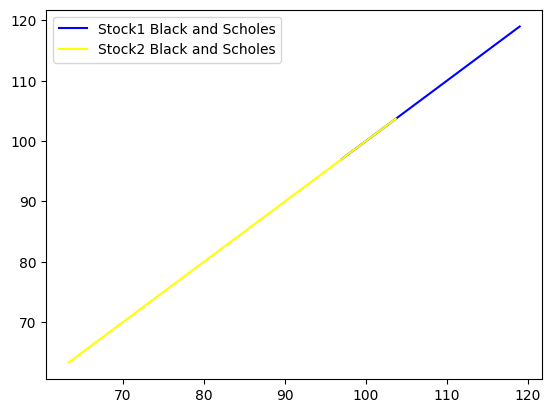

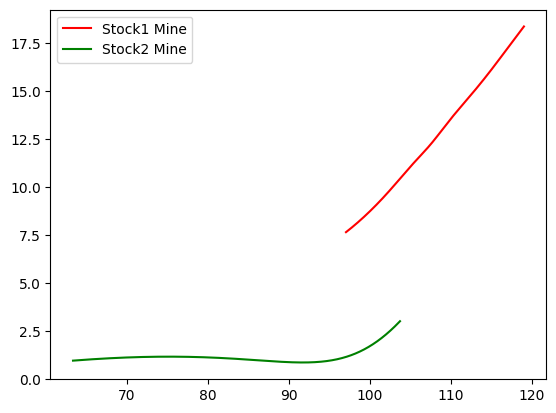

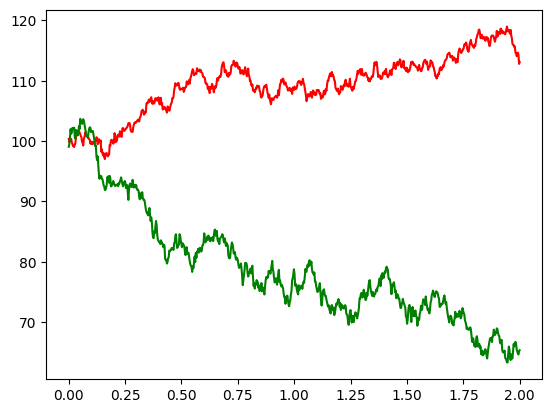

In [113]:
model.eval()

# Example: 5 specific points in time and space
t_vals  = np.linspace(0,2,750)
y1_vals = 100+np.cumsum(np.random.randn(750)*0.5+0.01)
y2_vals = 100+np.cumsum(np.random.randn(750)*0.7-0.01)
y1_vals=np.clip(y1_vals,0,200)
y2_vals=np.clip(y2_vals,0,200)
y1min=min(y1_vals)
y2min=min(y2_vals)
y1max=max(y1_vals)
y2max=max(y2_vals)
y1=np.linspace(y1min,y1max,750)
y2=np.linspace(y2min,y2max,750)


with torch.no_grad():
    # Convert to tensors and reshape to (N, 1) column vectors
    t_tensor  = torch.tensor(t_vals, dtype=torch.float32).view(-1, 1)
    y1_tensor = torch.tensor(y1, dtype=torch.float32).view(-1, 1)
    y2_tensor = torch.tensor(y2, dtype=torch.float32).view(-1, 1)
    w_preds1=model.forward(t_tensor,y1_tensor,y2_tensor)
    w_preds2=model.forward(t_tensor,y2_tensor,y1_tensor)

plt.plot(y1,black_scholes(y1),color="blue",label="Stock1 Black and Scholes")
plt.plot(y2,black_scholes(y2),color="yellow",label="Stock2 Black and Scholes")
plt.legend()
plt.show()
plt.plot(y1,w_preds1,color="red",label="Stock1 Mine")
plt.plot(y2,w_preds2,color="green",label="Stock2 Mine")
plt.legend()
plt.show()
plt.plot(t_vals,y1_vals,color="red")
plt.plot(t_vals,y2_vals,color="green")
plt.show()

In [117]:
def plot_option_heatmap(model, t_eval=0.0, price_min=50.0, price_max=150.0, resolution=150, strike_price=100.0):
    """
    Generates and plots a vectorized 2D heatmap of option prices w(y1, y2, t) at a specific time t.
    
    Parameters:
    - model: The trained PyTorch PINN model.
    - t_eval: The specific evaluation time (e.g., 0.0 for initial time, t0 for expiration).
    - price_min, price_max: The range of asset prices to display.
    - resolution: The density of the grid (resolution x resolution points).
    - strike_price: The option strike price (useful for overlaying boundary markers).
    """
    # Put the model in evaluation mode
    model.eval()
    
    # 1. Create a 1D grid for each asset price axis
    y1_axis = np.linspace(price_min, price_max, resolution)
    y2_axis = np.linspace(price_min, price_max, resolution)
    
    # 2. Build 2D coordinate matrices (Shape: resolution x resolution)
    Y1, Y2 = np.meshgrid(y1_axis, y2_axis)
    
    # 3. Flatten the grids into column vectors for the neural network batch input
    y1_flat = Y1.flatten()[:, None]
    y2_flat = Y2.flatten()[:, None]
    
    # Create a time vector filled entirely with our evaluation time
    t_flat = np.full_like(y1_flat, t_eval)
    
    # 4. Convert inputs to PyTorch tensors
    t_tensor = torch.tensor(t_flat, dtype=torch.float32)
    y1_tensor = torch.tensor(y1_flat, dtype=torch.float32)
    y2_tensor = torch.tensor(y2_flat, dtype=torch.float32)
    
    # 5. Execute vectorized model prediction in a single forward pass (no gradients needed)
    with torch.no_grad():
        w_pred_flat = model(t_tensor, y1_tensor, y2_tensor).numpy()
        
    # 6. Reshape predictions back into the original 2D grid shape
    W = w_pred_flat.reshape(Y1.shape)
    
    # 7. Render the Heatmap
    plt.figure(figsize=(10, 8))
    
    # Use pcolormesh for a beautiful continuous coordinate mapping
    heatmap = plt.pcolormesh(Y1, Y2, W, cmap='viridis', shading='auto')
    
    # Add Colorbar with label
    cbar = plt.colorbar(heatmap)
    cbar.set_label('Predicted Option Price ($w$)', rotation=270, labelpad=20, fontsize=12)
    
    # Add Strike Price Guideline Overlays
    plt.axvline(strike_price, color='white', linestyle='--', alpha=0.5, label=f'Strike Price = {strike_price}')
    plt.axhline(strike_price, color='white', linestyle='--', alpha=0.5)
    
    # Labels and Titles
    plt.title(f'Two-Asset PINN Option Price Heatmap (t = {t_eval})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Stock 1 Price ($Y_1$)', fontsize=12)
    plt.ylabel('Stock 2 Price ($Y_2$)', fontsize=12)
    
    plt.xlim(price_min, price_max)
    plt.ylim(price_min, price_max)
    plt.legend(loc='upper right', framealpha=0.3)
    plt.grid(True, which='both', linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


    with torch.no_grad():
        w_pred_flat = model(t_tensor, y2_tensor, y1_tensor).numpy()
        
    # 6. Reshape predictions back into the original 2D grid shape
    W = w_pred_flat.reshape(Y1.shape)
    
    # 7. Render the Heatmap
    plt.figure(figsize=(10, 8))
    
    # Use pcolormesh for a beautiful continuous coordinate mapping
    heatmap = plt.pcolormesh(Y1, Y2, W, cmap='viridis', shading='auto')
    
    # Add Colorbar with label
    cbar = plt.colorbar(heatmap)
    cbar.set_label('Predicted Option Price ($w$)', rotation=270, labelpad=20, fontsize=12)
    
    # Add Strike Price Guideline Overlays
    plt.axvline(strike_price, color='white', linestyle='--', alpha=0.5, label=f'Strike Price = {strike_price}')
    plt.axhline(strike_price, color='white', linestyle='--', alpha=0.5)
    
    # Labels and Titles
    plt.title(f'Two-Asset PINN Option Price Heatmap (t = {t_eval})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Stock 1 Price ($Y_1$)', fontsize=12)
    plt.ylabel('Stock 2 Price ($Y_2$)', fontsize=12)
    
    plt.xlim(price_min, price_max)
    plt.ylim(price_min, price_max)
    plt.legend(loc='upper right', framealpha=0.3)
    plt.grid(True, which='both', linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

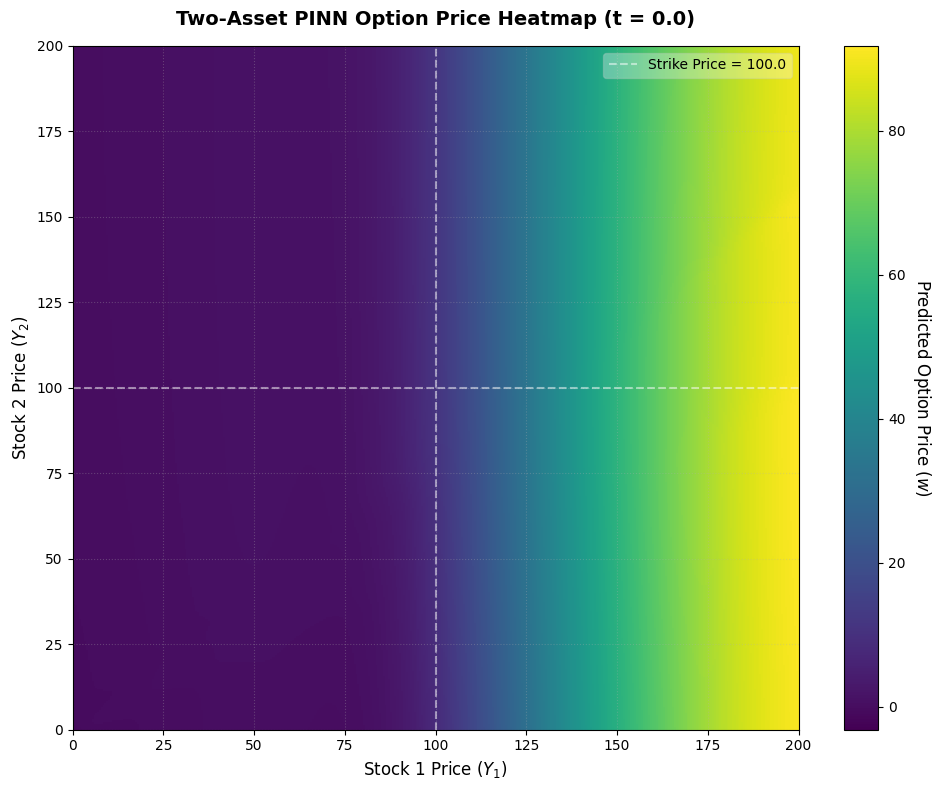

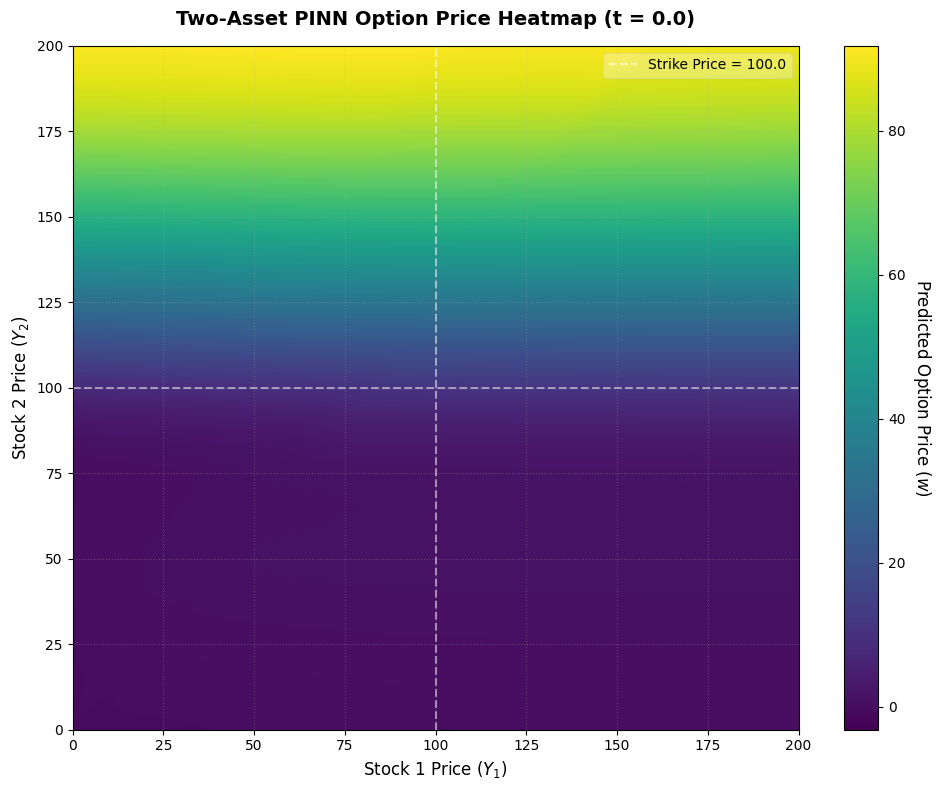

In [118]:
plot_option_heatmap(
    model=model, 
    t_eval=0.0,       # Evaluate at t = 0 (today)
    price_min=0,   # S1, S2 range min
    price_max=200,  # S1, S2 range max
    resolution=400,   # 200x200 grid evaluation (40,000 points computed instantly!)
    strike_price=100.0
)